In [1]:
# ==========================================
#  SYSTEM INSTALLATION & AUTH SETTINGS
# ==========================================

!pip install --upgrade fastapi uvicorn pyngrok pydantic pandas scikit-learn nest-asyncio -q

import os
import nest_asyncio
from pyngrok import ngrok

nest_asyncio.apply()

try:
    ngrok.kill()
    print("Flushed active historic network hooks clean.")
except Exception:
    pass

os.makedirs('models', exist_ok=True)


NGROK_TOKEN = "3DrMniIuOn3HuNAN7PSPohhsWP7_3pmv31w7JERiG6k83PZEc"
ngrok.set_auth_token(NGROK_TOKEN)

print("Part 1 complete. Storage paths initialized and ngrok token bound.")

Flushed active historic network hooks clean.
Part 1 complete. Storage paths initialized and ngrok token bound.


In [2]:
# ==========================================
# KAGGLE API DIRECT AUTOMATION
# ==========================================

import os
import zipfile

os.environ["KAGGLE_USERNAME"] = "mirzamuntasirm"
os.environ["KAGGLE_KEY"] = "KGAT_1dd3401f74d9f974722caf094fe025ba"

kaggle_config_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_config_dir, exist_ok=True)
token_path = os.path.join(kaggle_config_dir, "kaggle.json")

with open(token_path, "w") as f:
    f.write(f'{{"username":"{os.environ["KAGGLE_USERNAME"]}","key":"{os.environ["KAGGLE_KEY"]}"}}')
os.chmod(token_path, 0o600)

print("System credentials authenticated via direct string token map.")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi()
    api.authenticate()
    print("Kaggle Server API Handshake: SUCCESSFUL")
except Exception as auth_error:
    raise RuntimeError(f"Kaggle Auth Failed: {auth_error}. Please double-check your username or key string accuracy.")

dataset_identifier = "julian3833/jigsaw-toxic-comment-classification-challenge"
output_directory = "./data"
os.makedirs(output_directory, exist_ok=True)

print(f"Streaming package '{dataset_identifier}' directly from Kaggle server ports...")
try:
    api.dataset_download_files(dataset_identifier, path=output_directory, unzip=False)
    print("Download pipeline sequence finished.")
except Exception as download_error:
    raise RuntimeError(f"API data fetch rejected: {download_error}")

zip_package_path = os.path.join(output_directory, "jigsaw-toxic-comment-classification-challenge.zip")
if os.path.exists(zip_package_path):
    print("Extracting master zip archive layer...")
    with zipfile.ZipFile(zip_package_path, 'r') as master_zip:
        master_zip.extractall(output_directory)

nested_train_zip = os.path.join(output_directory, "train.csv.zip")
if os.path.exists(nested_train_zip):
    print("Extracting training matrix files ('train.csv')...")
    with zipfile.ZipFile(nested_train_zip, 'r') as inner_zip:
        inner_zip.extractall(output_directory)
    print("\n SUCCESS: 'train.csv' is extracted and completely ready for use!")
elif os.path.exists(os.path.join(output_directory, "train.csv")):
    print("\n SUCCESS: 'train.csv' extracted directly and completely ready for use!")
else:
    print("Error: Extraction failed. File path structure mismatch.")

System credentials authenticated via direct string token map.
Kaggle Server API Handshake: SUCCESSFUL
Streaming package 'julian3833/jigsaw-toxic-comment-classification-challenge' directly from Kaggle server ports...
Dataset URL: https://www.kaggle.com/datasets/julian3833/jigsaw-toxic-comment-classification-challenge
Download pipeline sequence finished.
Extracting master zip archive layer...

 SUCCESS: 'train.csv' extracted directly and completely ready for use!


 Successfully pulled 5000 rows of real-world training data!

First 5 rows of your production dataset:
                                        comment_text  is_toxic
0  Geez, are you forgetful!  We've already discus...         0
1  Carioca RFA \n\nThanks for your support on my ...         0
2  "\n\n Birthday \n\nNo worries, It's what I do ...         0
3  Pseudoscience category? \n\nI'm assuming that ...         0
4  (and if such phrase exists, it would be provid...         0


/tmp/ipykernel_15118/635262469.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_toxic', palette='viridis')


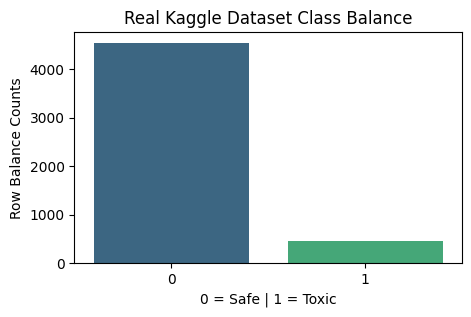

In [3]:
# ==========================================
# REAL DATASET LOADING & VISUALIZATION
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/train.csv')

df = df.rename(columns={'toxic': 'is_toxic'})

df['comment_text'] = df['comment_text'].fillna('')

df = df[['comment_text', 'is_toxic']].sample(n=5000, random_state=42).reset_index(drop=True)

print(f" Successfully pulled {len(df)} rows of real-world training data!")
print("\nFirst 5 rows of your production dataset:")
print(df.head())

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='is_toxic', palette='viridis')
plt.title("Real Kaggle Dataset Class Balance")
plt.xlabel("0 = Safe | 1 = Toxic")
plt.ylabel("Row Balance Counts")
plt.show()

In [4]:
# ==========================================
#  TRAINING PRODUCTION ENGINES
# ==========================================

import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

print("Executing isolation split routine...")
X_train, X_test, y_train, y_test = train_test_split(
    df['comment_text'], df['is_toxic'], test_size=0.20, random_state=42
)

print("Vectorizing raw text into numerical features...")
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Fitting baseline model (Logistic Regression)...")
baseline = LogisticRegression()
baseline.fit(X_train_vec, y_train)

print("Optimizing complex model via Grid Search (This may take up to 30 seconds)...")
rf = RandomForestClassifier(random_state=42)
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 5]}

grid_search = GridSearchCV(rf, param_grid, cv=2, scoring='f1')
grid_search.fit(X_train_vec, y_train)
best_model = grid_search.best_estimator_

preds = best_model.predict(X_test_vec)
print("\n=== PRODUCTION CAPSTONE METRICS ===")
print("Confusion Matrix Output:\n", confusion_matrix(y_test, preds))
print("\nClassification Target Metrics Summary:\n", classification_report(y_test, preds, zero_division=0))

with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)
with open('models/complex_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("\n Real-world serialized model objects saved safely to Colab storage!")

Executing isolation split routine...
Vectorizing raw text into numerical features...
Fitting baseline model (Logistic Regression)...
Optimizing complex model via Grid Search (This may take up to 30 seconds)...

=== PRODUCTION CAPSTONE METRICS ===
Confusion Matrix Output:
 [[900   9]
 [ 53  38]]

Classification Target Metrics Summary:
               precision    recall  f1-score   support

           0       0.94      0.99      0.97       909
           1       0.81      0.42      0.55        91

    accuracy                           0.94      1000
   macro avg       0.88      0.70      0.76      1000
weighted avg       0.93      0.94      0.93      1000


 Real-world serialized model objects saved safely to Colab storage!


In [5]:
%%writefile app.py
# ==========================================
#  BACKEND INTERFACE SCHEMA DEFINITION
# ==========================================

import os
import pickle
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel

app = FastAPI(
    title="Inference Engine Platform",
    description="Production Capstone Toxicity Verification Portal V1"
)

class TextSubmission(BaseModel):
    text: str

model = None
vectorizer = None

@app.on_event("startup")
def boot_inference_libraries():
    """Triggered automatically as soon as the server boots up to map models into memory."""
    global model, vectorizer
    m_path = "models/complex_model.pkl"
    v_path = "models/tfidf_vectorizer.pkl"

    if not os.path.exists(m_path) or not os.path.exists(v_path):
        raise RuntimeError("Missing serialized ML assets! Please verify Part 3 completed.")

    with open(m_path, "rb") as f:
        model = pickle.load(f)
    with open(v_path, "rb") as f:
        vectorizer = pickle.load(f)
    print("Production classification array mapped into memory successfully.")

@app.get("/")
def structural_health_handshake():
    """Basic landing path confirmation standard for testing server availability."""
    return {"status": "Online", "mode": "Production Containerized Environment"}

@app.post("/predict")
def score_incoming_payload(payload: TextSubmission):
    """Processes incoming runtime user strings and returns formal classification metrics."""
    if not payload.text.strip():
        raise HTTPException(status_code=400, detail="Input processing string cannot be null.")

    transformed_matrix = vectorizer.transform([payload.text])

    probabilities = model.predict_proba(transformed_matrix)[0]
    prediction = int(model.predict(transformed_matrix)[0])

    return {
        "text_parsed": payload.text,
        "classification": "Toxic" if prediction == 1 else "Safe / Non-Toxic",
        "confidence_distributions": {
            "safe_probability": round(float(probabilities[0]), 4),
            "toxic_probability": round(float(probabilities[1]), 4)
        }
    }

Overwriting app.py


In [6]:
# ==========================================
#  ISOLATED SYSTEM LAUNCH & TUNNELING
# ==========================================

import subprocess
import time
from pyngrok import ngrok

print("1. Force flushing legacy cloud edge tunnels...")
try:
    tunnels = ngrok.get_tunnels()
    for tunnel in tunnels:
        ngrok.disconnect(tunnel.public_url)
    print("Cloud routing lines cleared successfully.")
except Exception:
    pass

print("\n2. Launching FastAPI as an isolated system process...")
backend_process = subprocess.Popen(
    ["uvicorn", "app:app", "--host", "127.0.0.1", "--port", "8000", "--log-level", "info"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

print("Warming up isolated server core framework...")
time.sleep(5)

if backend_process.poll() is not None:
    print("\n CRITICAL: Server failed to start. Printing raw error trace log:")
    print(backend_process.stdout.read())
else:
    print("Backend engine verified running stable in isolated workspace process.")

    try:
        public_gateway_url = ngrok.connect(8000, bind_tls=True).public_url
        print("\n" + "="*80)
        print(f"  WEB INFRASTRUCTURE IS COMPLETELY ONLINE AND LIVE!")
        print(f" BASE URL    : {public_gateway_url}")
        print(f" API PLAYGROUND/DEMO LINK : {public_gateway_url}/docs")
        print("="*80 + "\n")
    except Exception as network_error:
        print(f"Tunnel allocation failed: {network_error}")

1. Force flushing legacy cloud edge tunnels...
Cloud routing lines cleared successfully.

2. Launching FastAPI as an isolated system process...
Warming up isolated server core framework...
Backend engine verified running stable in isolated workspace process.

  WEB INFRASTRUCTURE IS COMPLETELY ONLINE AND LIVE!
 BASE URL    : https://food-blouse-sphere.ngrok-free.dev
 API PLAYGROUND/DEMO LINK : https://food-blouse-sphere.ngrok-free.dev/docs

